# Multi-Period Production Planning Under Uncertainty

This notebook demonstrates solving the extended production planning problem over a 3-period horizon with time-varying demand forecasts.

## Problem Overview
- **Products**: 2 products with different selling prices and excess costs
- **Time Horizon**: 3 periods
- **Demand**: Stochastic with time-varying means
- **Objective**: Maximize profit while managing risk

In [1]:
# Import the multi-period solver
from multi_period_solver import MultiPeriodProductionSolver, OptimizationMode
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## Problem Setup

### Initial Inventory
Starting inventory levels at the beginning of period 1.

### Demand Forecast
The demand for each product follows a multiplicative noise model:
$D_{i,t} = \mu_{i,t} \cdot \epsilon_{i,t}$ where $\epsilon \sim \text{Normal}(1, \sigma_t)$ truncated to $[0, 2]$

Uncertainty grows with forecast horizon: $\sigma_t = 0.1 + 0.05 \cdot t$

| Product | Period 1 | Period 2 | Period 3 |
|---------|----------|----------|----------|
| 1       | 7,000    | 6,000    | 5,000    |
| 2       | 10,500   | 9,000    | 10,000   |

### Economics
| Product | Selling Price | Holding Cost | Excess Cost |
|---------|---------------|--------------|-------------|
| 1       | $0.30         | $0.50        | $2.70       |
| 2       | $0.45         | $1.00        | $6.00       |

In [2]:
# Define initial inventory levels (modify these values as needed)
initial_inventory = {
    1: 5000,   # Product 1 starting inventory
    2: 9500,  # Product 2 starting inventory
}
demand_means = {
        1: [7000, 6000, 5000],
        2: [10500, 9000, 10000],
    }
num_periods = 3

'''
# try longer period forecasts
demand_means = {
        1: [7000, 6000, 5000, 8000, 5000],
        2: [10500, 9000, 10000,6000,5000],
    }
num_periods = 5
'''

# Create the solver with configurable parameters
solver = MultiPeriodProductionSolver(
    num_periods=num_periods,
    demand_means=demand_means,
    initial_inventory=initial_inventory,
    number_scenarios=10000,
    time_limit=15,
)

# Display initial inventory
print("Initial Inventory:")
print(f"  Product 1: {solver.initial_inventory[1]:,} units")
print(f"  Product 2: {solver.initial_inventory[2]:,} units")
print()

# Display demand forecast
demand_df = pd.DataFrame({
    'Period': list(range(1, num_periods + 1)),
    'Product 1 Mean': solver.demand_means[1],
    'Product 2 Mean': solver.demand_means[2],
})
print("Demand Forecast:")
display(demand_df)

Initial Inventory:
  Product 1: 5,000 units
  Product 2: 9,500 units

Demand Forecast:


,Period,Product 1 Mean,Product 2 Mean
0,1,7000,10500
1,2,6000,9000
2,3,5000,10000


## Run Optimization

We'll compare four optimization modes:
1. **Deterministic**: Evaluate at initial (naive) solution
2. **Maximize Expected Profit**: Optimize E[Profit]
3. **Maximize CVaR**: Risk-aware optimization (worst 5% scenarios)
4. **Multi-Objective**: Balance expected profit and CVaR using desirability functions

In [3]:
# Run all three optimization modes
modes = [
    OptimizationMode.DETERMINISTIC,
    OptimizationMode.MAXIMIZE_EXPECTED_PROFIT,
    OptimizationMode.MAXIMIZE_CVAR,
    OptimizationMode.MULTI_OBJECTIVE,
]

results = {}
for mode in modes:
    results[mode.value] = solver.solve(mode)

    # set parameters for multi-objective
    if mode.value == OptimizationMode.MAXIMIZE_EXPECTED_PROFIT.value:
        # excellent profit, fair CVaR from max.profit solution
        solver.excellent_exp_profit = results[mode.value]['expected_profit']
        solver.fair_cvar = results[mode.value]['cvar_5']
    if mode.value == OptimizationMode.MAXIMIZE_CVAR.value:
        # fair profit, excellent CVaR from max.CVaR solution
        solver.fair_exp_profit = results[mode.value]['expected_profit']
        solver.excellent_cvar = results[mode.value]['cvar_5']


Evaluating deterministically...

Mode: deterministic
------------------------------------------------------------
Production Plan:
  Period   Prod 1     Prod 2     Inv 1      Inv 2     
  1        1700       850        152        346       
  2        5058       7331       107        151       
  3        4250       8500       176        313       

Expected Profits by Period:
  Period 1: $6,044.24
  Period 2: $4,713.28
  Period 3: $2,252.40

Total Expected Profit: $13,009.92
VaR 5%: $-44.31
CVaR 5%: $-6,928.65

Optimizing expected profit...
At time 4.992903: Objective = 14431.147569; Status = Feasible; Evaluations = 3301
At time 8.743906: Objective = 14432.349175; Status = Feasible; Evaluations = 6226
At time 12.581852: Objective = 14433.765649; Status = Feasible; Evaluations = 9107

Mode: maximize_expected_profit
------------------------------------------------------------
Production Plan:
  Period   Prod 1     Prod 2     Inv 1      Inv 2     
  1        1734       277        164   

## Results Summary

### Comparison of Optimization Modes

In [4]:
# Display summary table
summary = solver.get_summary()
display(summary[['mode', 'expected_profit', 'var_5', 'cvar_5', 'std_profit']])

,mode,expected_profit,var_5,cvar_5,std_profit
0,deterministic,13009.917562,-44.306091,-6928.649394,5960.652935
1,maximize_expected_profit,14434.080934,10489.706325,4879.215553,2746.939339
2,maximize_CVaR,13009.464718,12287.521753,11299.378783,673.709599
3,multi_objective,14133.048906,12344.596893,9985.065328,1378.879686


### Production Plans by Period

Compare optimal production quantities across different optimization modes:

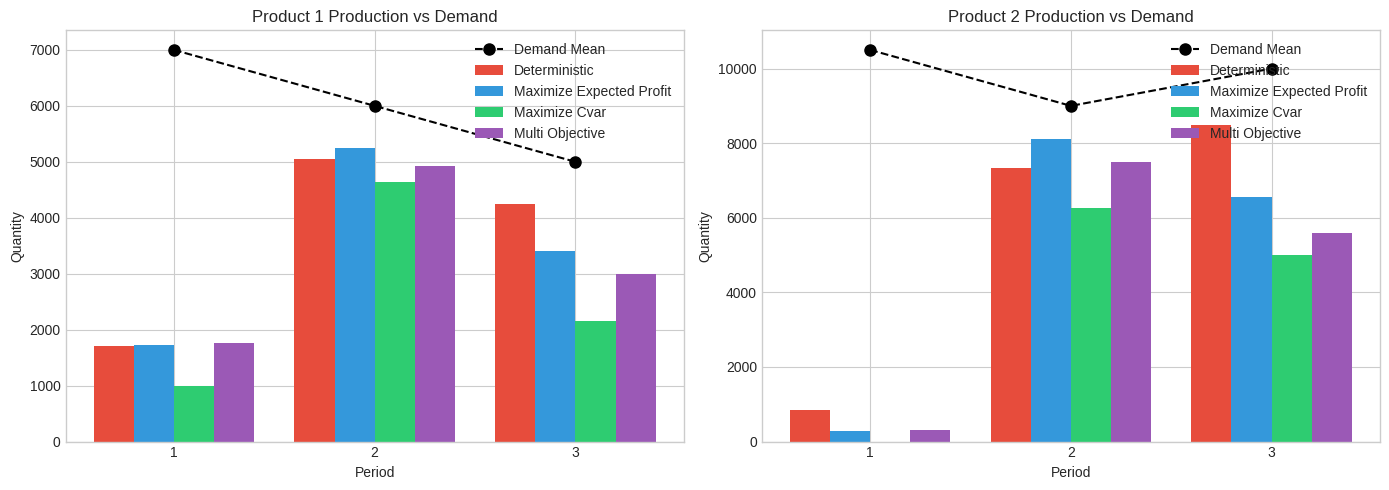

In [5]:
# Visualize production plans
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

periods = range(1, num_periods + 1)
mode_names = ['deterministic', 'maximize_expected_profit', 'maximize_CVaR', 'multi_objective']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']  # 4 colors for 4 modes

# Product 1
ax1 = axes[0]
x = np.arange(len(periods))
width = 0.2  # Adjusted for 4 bars

for i, mode in enumerate(mode_names):
    quantities = [results[mode]['solution'][(1, t)] for t in periods]
    ax1.bar(x + i*width, quantities, width, label=mode.replace('_', ' ').title(), color=colors[i])

ax1.plot(x + 1.5*width, solver.demand_means[1], 'ko--', markersize=8, label='Demand Mean')
ax1.set_xlabel('Period')
ax1.set_ylabel('Quantity')
ax1.set_title('Product 1 Production vs Demand')
ax1.set_xticks(x + 1.5*width)
ax1.set_xticklabels(periods)
ax1.legend(loc='upper right')

# Product 2
ax2 = axes[1]
for i, mode in enumerate(mode_names):
    quantities = [results[mode]['solution'][(2, t)] for t in periods]
    ax2.bar(x + i*width, quantities, width, label=mode.replace('_', ' ').title(), color=colors[i])

ax2.plot(x + 1.5*width, solver.demand_means[2], 'ko--', markersize=8, label='Demand Mean')
ax2.set_xlabel('Period')
ax2.set_ylabel('Quantity')
ax2.set_title('Product 2 Production vs Demand')
ax2.set_xticks(x + 1.5*width)
ax2.set_xticklabels(periods)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Profit Distribution Comparison

The profit distributions show the range of possible outcomes under each optimization strategy:

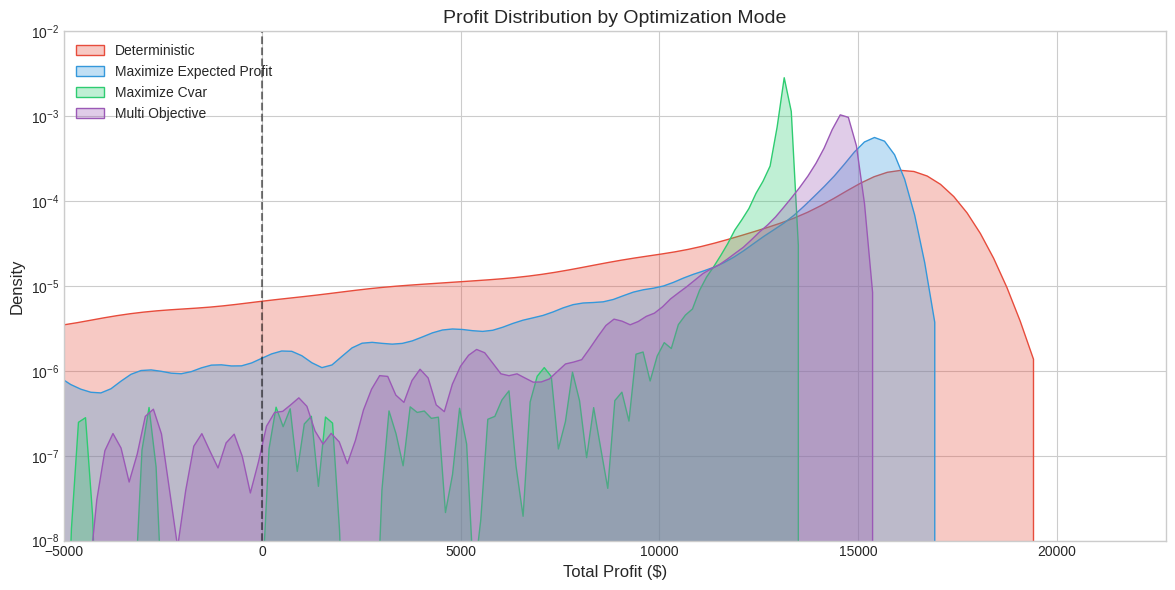

In [6]:
# Plot profit distributions
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']  # 4 colors for 4 modes

for col, color in zip(solver.results.columns, colors):
    sns.kdeplot(solver.results[col], ax=ax, fill=True, alpha=0.3,
                label=col.replace('profit_', '').replace('_', ' ').title(),
                color=color)

ax.set_xlabel('Total Profit ($)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Profit Distribution by Optimization Mode', fontsize=14)
ax.legend(loc='upper left')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Break-even')
plt.tight_layout()
plt.yscale("log")
plt.xlim(left=-5000)
plt.ylim(bottom=1e-8,top=1e-2)
plt.show()


### Multi-Objective Analysis

The multi-objective optimization balances expected profit and CVaR using desirability functions:
- **Fair level**: Minimum acceptable performance
- **Excellent level**: Ideal target performance

This approach finds Pareto-efficient solutions that trade off between the two objectives.

In [7]:
# Display multi-objective results in detail
mo_result = results['multi_objective']
ep_result = results['maximize_expected_profit']
cvar_result = results['maximize_CVaR']

print("Multi-Objective Solution Analysis")
print("=" * 60)
print(f"\nExpected Profit: ${mo_result['expected_profit']:,.2f}")
print(f"  vs Max Expected Profit: ${ep_result['expected_profit']:,.2f} ({100*(mo_result['expected_profit']/ep_result['expected_profit']-1):+.1f}%)")
print(f"\nCVaR 5%: ${mo_result['cvar_5']:,.2f}")
print(f"  vs Max CVaR: ${cvar_result['cvar_5']:,.2f} ({100*(mo_result['cvar_5']/cvar_result['cvar_5']-1):+.1f}%)")
print(f"\nProduction Plan:")
for t in range(3):
    p1 = mo_result['solution'][(1, t+1)]
    p2 = mo_result['solution'][(2, t+1)]
    print(f"  Period {t+1}: Product 1 = {p1:,.0f}, Product 2 = {p2:,.0f}")

print(f"\nExpected Ending Inventory:")
for t in range(3):
    i1 = mo_result['expected_inventory'][(1, t+1)]
    i2 = mo_result['expected_inventory'][(2, t+1)]
    print(f"  Period {t+1}: Product 1 = {i1:,.0f}, Product 2 = {i2:,.0f}")

Multi-Objective Solution Analysis

Expected Profit: $14,133.05
  vs Max Expected Profit: $14,434.08 (-2.1%)

CVaR 5%: $9,985.07
  vs Max CVaR: $11,299.38 (-11.6%)

Production Plan:
  Period 1: Product 1 = 1,763, Product 2 = 314
  Period 2: Product 1 = 4,934, Product 2 = 7,492
  Period 3: Product 1 = 3,000, Product 2 = 5,587

Expected Ending Inventory:
  Period 1: Product 1 = 174, Product 2 = 161
  Period 2: Product 1 = 91, Product 2 = 129
  Period 3: Product 1 = 16, Product 2 = 13


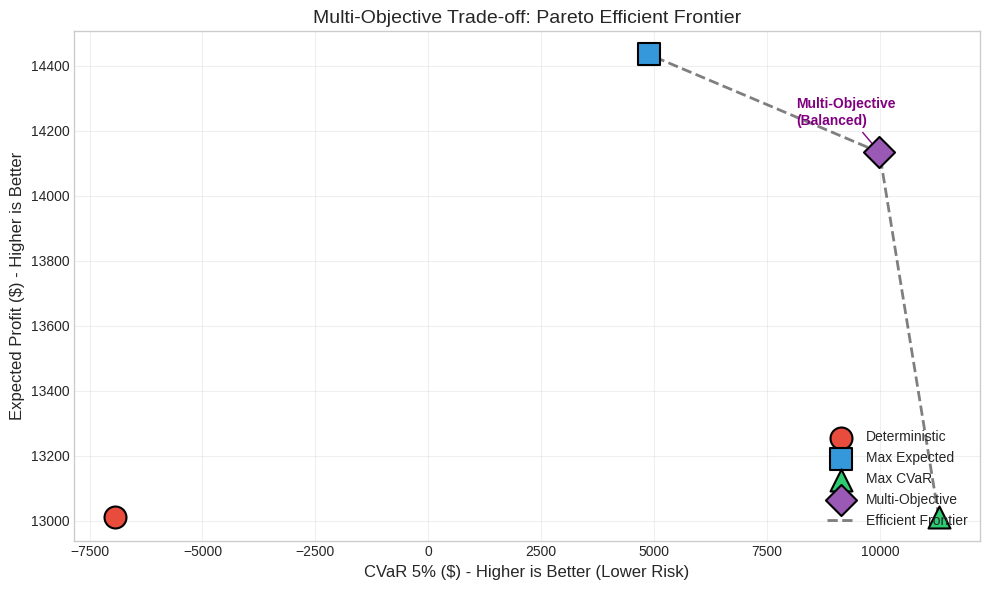

In [8]:
# Visualize multi-objective trade-off with Pareto frontier
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
markers = ['o', 's', '^', 'D']
mode_labels = ['Deterministic', 'Max Expected', 'Max CVaR', 'Multi-Objective']

for i, (mode, result) in enumerate(results.items()):
    ax.scatter(result['cvar_5'], result['expected_profit'],
               s=250, c=colors[i], marker=markers[i], edgecolors='black',
               linewidths=1.5, label=mode_labels[i], zorder=5)

# Draw lines connecting the efficient solutions
efficient_modes = ['maximize_CVaR', 'multi_objective', 'maximize_expected_profit']
cvar_vals = [results[m]['cvar_5'] for m in efficient_modes]
exp_vals = [results[m]['expected_profit'] for m in efficient_modes]
ax.plot(cvar_vals, exp_vals, 'k--', alpha=0.5, linewidth=2, label='Efficient Frontier')

# Highlight multi-objective position
mo = results['multi_objective']
ax.annotate('Multi-Objective\n(Balanced)', (mo['cvar_5'], mo['expected_profit']),
            textcoords="offset points", xytext=(-60, 20), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='purple'),
            fontweight='bold', color='purple')

ax.set_xlabel('CVaR 5% ($) - Higher is Better (Lower Risk)', fontsize=12)
ax.set_ylabel('Expected Profit ($) - Higher is Better', fontsize=12)
ax.set_title('Multi-Objective Trade-off: Pareto Efficient Frontier', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Expected Profit by Period

Breakdown of expected profit contribution from each period:

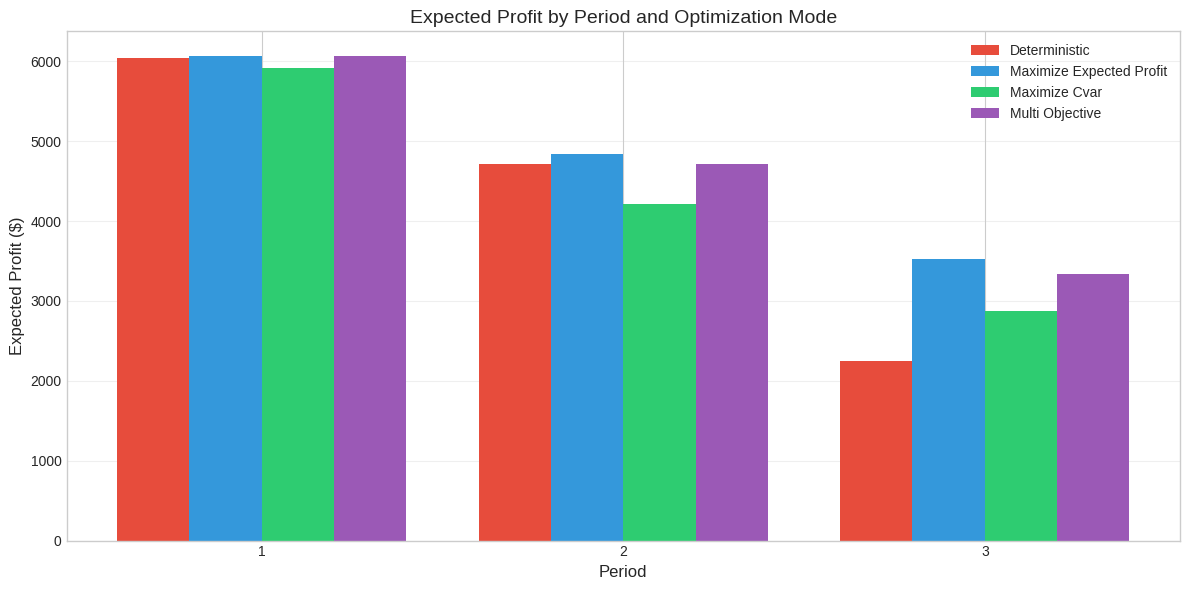

In [9]:
# Period-by-period profit breakdown
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(periods))
width = 0.2  # Adjusted for 4 bars
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']  # 4 colors for 4 modes

for i, mode in enumerate(mode_names):
    period_profits = results[mode]['period_profits']
    ax.bar(x + i*width, period_profits, width,
           label=mode.replace('_', ' ').title(), color=colors[i])

ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Expected Profit ($)', fontsize=12)
ax.set_title('Expected Profit by Period and Optimization Mode', fontsize=14)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(periods)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions

### Key Observations:

1. **Deterministic (Naive) Solution**: Produces at mean demand levels, resulting in high variability and significant downside risk (negative CVaR).

2. **Maximize Expected Profit**: Produces below mean demand to avoid costly excess inventory. Achieves highest expected profit but with some downside risk.

3. **Maximize CVaR**: Most conservative strategy with lowest production quantities. Sacrifices some expected profit for much better worst-case performance.

4. **Multi-Objective**: Balances expected profit and CVaR using a desirability function. Achieves near-optimal expected profit while significantly improving worst-case outcomes compared to pure expected profit maximization.

### Trade-off Analysis:
- The CVaR-optimized solution has ~10% lower expected profit but nearly eliminates the risk of losses
- The expected-profit solution is optimal for risk-neutral decision makers
- The CVaR solution is preferred when avoiding worst-case scenarios is critical
- The multi-objective solution offers a balanced compromise: higher expected profit than CVaR-only, better risk protection than expected-profit-only

In [10]:
# Final detailed summary
print("=" * 70)
print("FINAL SUMMARY: Multi-Period Production Planning")
print("=" * 70)
display(solver.get_summary().round(2))

FINAL SUMMARY: Multi-Period Production Planning


,mode,expected_profit,var_5,cvar_5,mean_profit,std_profit,min_profit,max_profit,q1_t1,q2_t1,q1_t2,q2_t2,q1_t3,q2_t3,inv1_t1,inv2_t1,inv1_t2,inv2_t2,inv1_t3,inv2_t3
0,deterministic,13009.92,-44.31,-6928.65,13009.92,5960.65,-44316.08,16583.85,1700.0,850.0,5058.0,7331.0,4250.0,8500.0,151.91,346.02,106.63,151.07,175.91,313.00
1,maximize_expected_profit,14434.08,10489.71,4879.22,14434.08,2746.94,-32102.98,15625.95,1734.0,277.0,5248.0,8120.0,3413.0,6564.0,163.65,151.78,153.65,267.98,48.73,59.45
2,maximize_CVaR,13009.46,12287.52,11299.38,13009.46,673.71,-21545.24,13176.45,991.0,0.0,4646.0,6263.0,2152.0,4992.0,21.98,95.70,28.26,16.53,0.53,3.73
3,multi_objective,14133.05,12344.60,9985.07,14133.05,1378.88,-24469.04,14710.95,1763.0,314.0,4934.0,7492.0,3000.0,5587.0,174.17,160.97,90.75,128.89,16.03,13.35
